# ❤️ HEART DISEASE PREDICTOR
### ML Classification + Gemini AI + Streamlit

---

**What this project does:**
1. Takes the Cleveland Heart Disease dataset (just like adult.csv was income data)
2. Cleans it, does EDA, trains Logistic Regression + Random Forest
3. Launches a Streamlit app where:
   - User enters their health details
   - ML model predicts: **Heart Disease or No Heart Disease**
   - Gemini explains the result in simple words + gives diet/lifestyle tips

**Everything here is the same as your AICTE notebook — same libraries, same steps. Only the dataset and Streamlit UI are new.**

## STEP 1 — INSTALL LIBRARIES

In [1]:
!pip install streamlit google-generativeai joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 129.4 MB/s eta 0:00:00


## STEP 2 — IMPORT LIBRARIES
Exact same imports as AICTE_1. Nothing new here.

In [2]:
# ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── NEW: to save and load the trained model ──────────────────
# joblib saves your trained model to a file so Streamlit can use it later
import joblib

print('✅ All libraries imported!')

✅ All libraries imported!


## STEP 3 — LOAD DATASET

**About the dataset:**
- Called the **Cleveland Heart Disease dataset** (from Kaggle / UCI)
- 303 rows, 14 columns
- Target column: `target` → 1 = Heart Disease, 0 = No Heart Disease
- Just like adult.csv had an `income` column as target!

**Download from Kaggle:**
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Upload the file to Colab, then run this cell.

In [3]:
data = pd.read_csv('heart.csv')   # upload heart.csv to Colab first!

print('Shape:', data.shape)
print('\nFirst 3 rows:')
print(data.head(3))
print('\nLast 3 rows:')
print(data.tail(3))
print('\nColumn names:')
print(data.columns.tolist())

Shape: (1025, 14)

First 3 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  

Last 3 rows:
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
1022      1   1     2       0  
1023      2   0     2       1  
1024      1   1     3       0  

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak'

## STEP 4 — EDA (EXPLORATORY DATA ANALYSIS)

### What each column means (important for interview!)

| Column | Meaning |
|--------|----------|
| age | Age of patient |
| sex | 1 = Male, 0 = Female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure |
| chol | Cholesterol level |
| fbs | Fasting blood sugar > 120 mg/dl (1=True, 0=False) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced chest pain (1=Yes, 0=No) |
| oldpeak | ST depression |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels (0-3) |
| thal | Thal type (0-3) |
| **target** | **1 = Heart Disease, 0 = No Heart Disease** |

In [4]:
# ── NULL VALUE CHECK ───────────────────────
print('── Null Values ──')
print(data.isna().sum())

# ── DUPLICATE CHECK ────────────────────────
print('\n── Duplicates ──')
print(data.duplicated().sum())
data.drop_duplicates(inplace=True)
print('Duplicates removed ✅')

# ── BASIC STATS ───────────────────────────────────────────────
print('\n── Basic Statistics ──')
print(data.describe())

── Null Values ──
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

── Duplicates ──
723
Duplicates removed ✅

── Basic Statistics ──
             age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000  

## STEP 5 — EDA VISUALIZATIONS
Same plots as AICTE_1 — distributions, correlation heatmap, target balance.

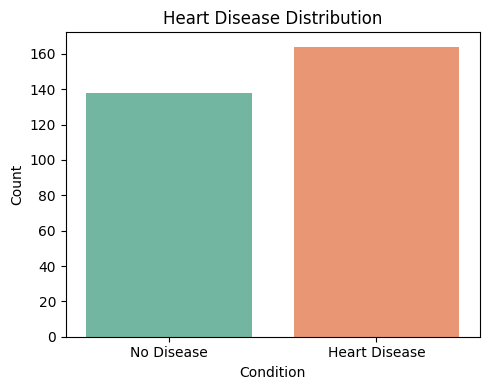

Saved target_distribution.png ✅


In [5]:
# ── PLOT 1: TARGET BALANCE ────────────────────────────────────
# Shows how many people have heart disease vs don't
plt.figure(figsize=(5, 4))
sns.countplot(x='target', data=data, palette='Set2')
plt.title('Heart Disease Distribution')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.xlabel('Condition')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()
print('Saved target_distribution.png ✅')

**numeric_cols = data.select_dtypes(include=np.number).columns.tolist()**

 What it does: Goes through all columns in your dataframe and picks only the ones that contain numbers (int, float). Stores their names as a list.

Example — if your columns are [age, sex, cp, chol, target] and all are numeric, numeric_cols becomes ['age', 'sex', 'cp', 'chol', 'target']

🎯 Think of it like: from your whole class, pick only students who scored above 90. Here, from all columns, pick only numeric ones.

**numeric_cols = [c for c in numeric_cols if c != 'target']**

 What it does: Removes 'target' from the list. We don't want to plot the target column — it only has 0s and 1s, so its histogram would look weird and useless.

This is a list comprehension — short way of writing a for loop that filters a list.

**Same as writing:**

####
    new_list = []
    for c in numeric_cols:
    if c != 'target': new_list.append(c)
🎯 Think of it like: keep everyone in the list EXCEPT the monitor.

**fig, axes = plt.subplots(3, 4, figsize=(16, 10))**

slightly new What it does: Creates a grid of 3 rows × 4 columns = 12 small plots all at once, inside one big figure.

— fig = the whole big canvas (like an A4 sheet)

— axes = a 3×4 grid of individual plot boxes on that canvas

— figsize=(16,10) = width 16 inches, height 10 inches (same as you've used before)

We need 12 boxes because we have 13 features and want one histogram per feature.

🎯 Think of it like: booking 12 seats in a cinema hall arranged in 3 rows × 4 columns. Each seat = one plot.

**axes = axes.flatten()**

slightly new What it does: axes right now is a 2D grid (3 rows × 4 cols). .flatten() converts it into a simple 1D list of 12 boxes.

Before flatten: [[ax1,ax2,ax3,ax4], [ax5,ax6,...], [ax9,...]]

After flatten:  [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12]

Why? Because now we can loop through them simply using axes[0], axes[1], etc. instead of axes[0][0], axes[0][1]...

🎯 Think of it like: a 3×4 seating chart (rows and columns) vs a single waiting queue of 12 people. Queue is easier to loop through!

    for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=20, color='#5B8DEF', edgecolor='white')
    axes[i].set_title(col)
    
you know this What it does: Loops through every column name and draws one histogram in the matching plot box.

— **enumerate(numeric_cols)** gives both the index number (i=0,1,2...) and the column name at the same time

— axes[i] = the i-th plot box in our flattened list

— .hist(...) = draw a histogram in that box (same as plt.hist you already know!)

— data[col].dropna() = get column values, drop any NaN (same as AICTE_1)

— bins=20 = divide the data into 20 bars

— axes[i].set_title(col) = put the column name as the title of that box

🎯 Think of it like: for each student (column), go to their assigned seat (axes[i]) and draw their score chart there.
for j in range(i+1, len(axes)):

    axes[j].set_visible(False)

slightly new What it does: Hides any leftover empty boxes.

We have 12 boxes but only ~13 columns (minus target = 13 features). If features don't divide perfectly into 12, some boxes at the end stay empty and look ugly. This loop finds those extras and hides them.

— After the first loop ends, i = index of the last column we plotted

— range(i+1, len(axes)) = all box numbers after the last used one

— set_visible(False) = make that box invisible

plt.suptitle('Feature Distributions', fontsize=14)

plt.tight_layout()

plt.savefig('distributions.png')

plt.show()

you know this What it does:

— plt.suptitle() = adds ONE big title for the entire grid (super title = title above all subplots)

— plt.tight_layout() = automatically adjusts spacing so plots don't overlap each other

— plt.savefig() = saves the whole grid as an image file

— plt.show() = displays it in Colab — same as always!



IndexError: index 12 is out of bounds for axis 0 with size 12

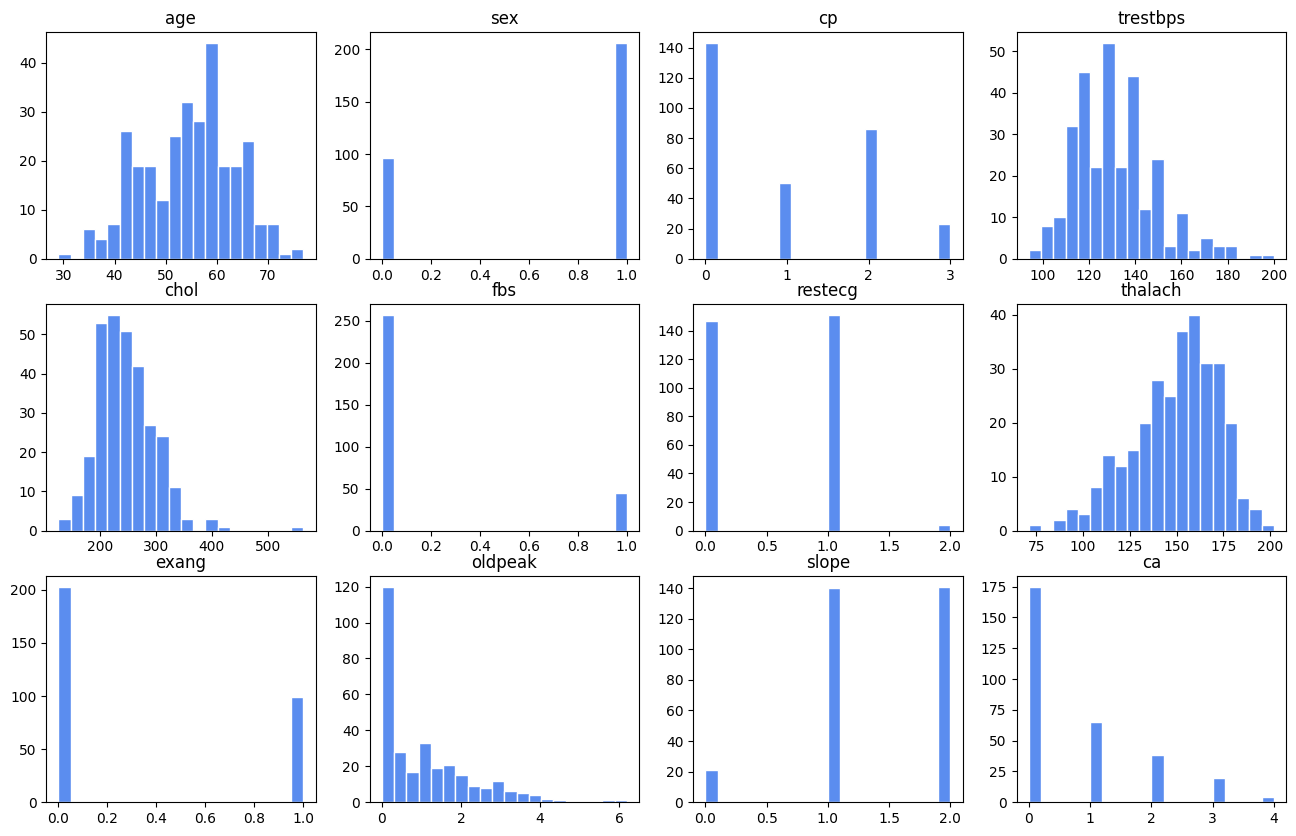

In [6]:
# ── PLOT 2: NUMERIC DISTRIBUTIONS ──────────
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=20, color='#5B8DEF', edgecolor='white')
    axes[i].set_title(col)

# hide any extra blank plots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()
print('Saved distributions.png ✅')

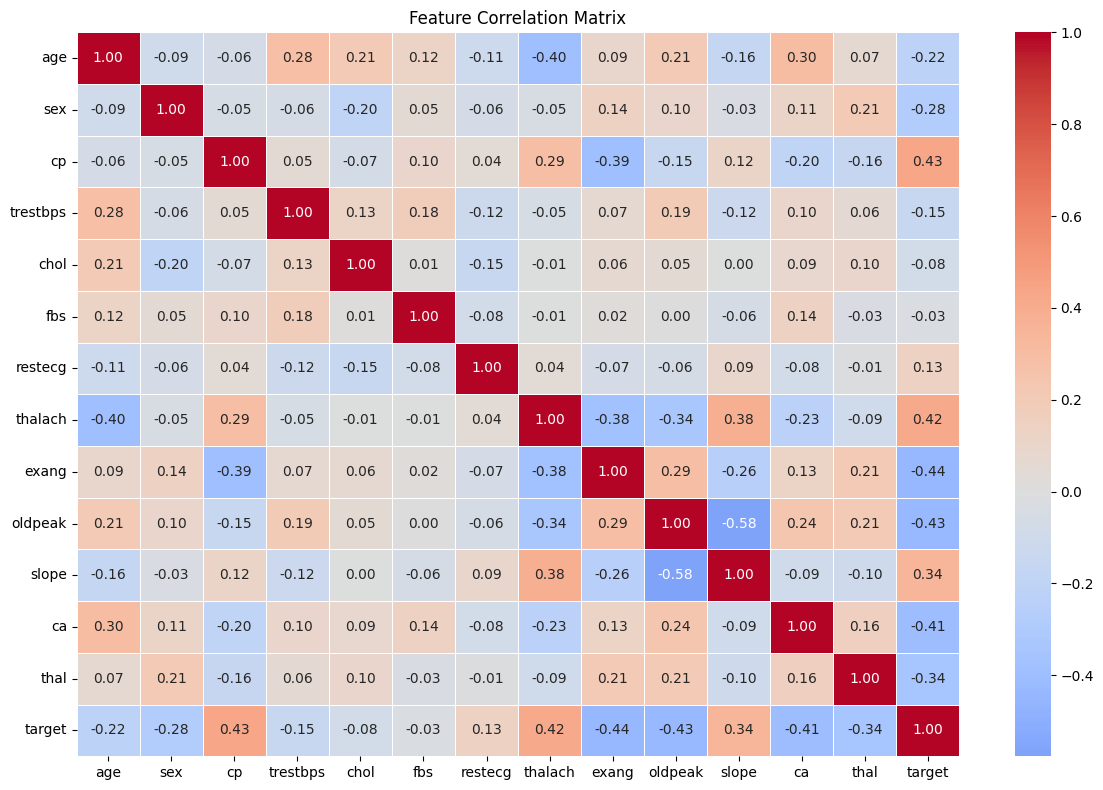

Saved correlation.png ✅


In [7]:
# ── PLOT 3: CORRELATION HEATMAP ─────────────
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation.png')
plt.show()
print('Saved correlation.png ✅')

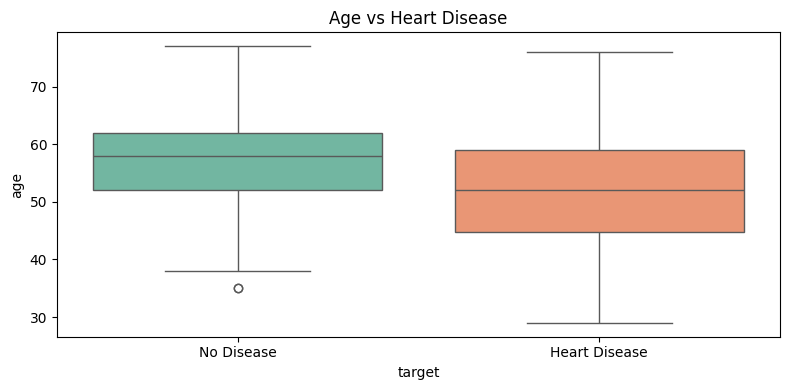

Saved age_vs_target.png ✅


In [8]:
# ── PLOT 4: AGE vs HEART DISEASE ─────────────────────────────
# Extra insight: do older people have more heart disease?
plt.figure(figsize=(8, 4))
sns.boxplot(x='target', y='age', data=data, palette='Set2')
plt.title('Age vs Heart Disease')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.savefig('age_vs_target.png')
plt.show()
print('Saved age_vs_target.png ✅')

## STEP 6 — DATA CLEANING
Same 3 steps as AICTE_1: fill nulls → fix outliers → encode categories.

In [9]:
# ── STEP 6a: FILL NULL VALUES ──────────────
for col in data.select_dtypes(include=np.number).columns:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)
        print(f"Filled null in '{col}' with median ✅")

print('Null check after fill:', data.isnull().sum().sum(), 'nulls remaining')

Null check after fill: 0 nulls remaining


In [10]:
# ── STEP 6b: OUTLIER CLIPPING  ──────────────
# Using the same IQR method you learnt
for col in data.select_dtypes(include=np.number).columns:
    if col == 'target':
        continue   # never clip the target column!
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    if outliers > 0:
        data[col] = data[col].clip(lower=lower, upper=upper)
        print(f"Fixed outliers in '{col}' ✅")

print('\nData shape after cleaning:', data.shape)

Fixed outliers in 'trestbps' ✅
Fixed outliers in 'chol' ✅
Fixed outliers in 'fbs' ✅
Fixed outliers in 'thalach' ✅
Fixed outliers in 'oldpeak' ✅
Fixed outliers in 'ca' ✅
Fixed outliers in 'thal' ✅

Data shape after cleaning: (302, 14)


In [11]:
# ── STEP 6c: LABEL ENCODE CATEGORICAL COLUMNS
# This dataset is mostly numeric already, but we handle any object columns
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])
    print(f"Encoded '{col}' ✅")

print('\n✅ Cleaning complete!')
print(data.head(3))


✅ Cleaning complete!
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   52    1   0       125  212.0    0        1    168.0      0      1.0   
1   53    1   0       140  203.0    0        0    155.0      1      3.1   
2   70    1   0       145  174.0    0        1    125.0      1      2.6   

   slope   ca  thal  target  
0      2  2.0   3.0       0  
1      0  0.0   3.0       0  
2      0  0.0   3.0       0  


## STEP 7 — TRAIN/TEST SPLIT + MODEL TRAINING
100% same as AICTE_1. Only difference: target column is `target` instead of `income`.

In [12]:
X = data.drop(columns=['target'])
y = data['target']

# Train-test split 80/20 — same as AICTE_1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

# ── LOGISTIC REGRESSION ────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# ── RANDOM FOREST  ──────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('\n✅ Both models trained!')

Training samples : 241
Testing samples  : 61

✅ Both models trained!


## STEP 8 — MODEL EVALUATION
Accuracy, classification report, confusion matrix — exact same as AICTE_1.

In [13]:
print('=' * 50)
print('  LOGISTIC REGRESSION RESULTS')
print('=' * 50)
print(f'Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred,
      target_names=['No Disease', 'Heart Disease']))

print('=' * 50)
print('  RANDOM FOREST RESULTS')
print('=' * 50)
print(f'Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred,
      target_names=['No Disease', 'Heart Disease']))

  LOGISTIC REGRESSION RESULTS
Accuracy : 81.97%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.75      0.81        32
Heart Disease       0.76      0.90      0.83        29

     accuracy                           0.82        61
    macro avg       0.83      0.82      0.82        61
 weighted avg       0.83      0.82      0.82        61

  RANDOM FOREST RESULTS
Accuracy : 85.25%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.90      0.81      0.85        32
Heart Disease       0.81      0.90      0.85        29

     accuracy                           0.85        61
    macro avg       0.85      0.85      0.85        61
 weighted avg       0.86      0.85      0.85        61



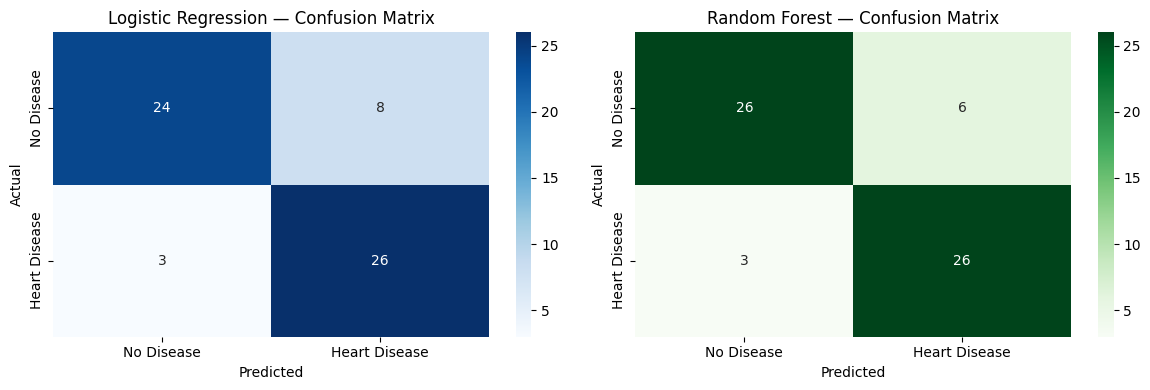

Saved confusion_matrices.png ✅


In [14]:
# ── CONFUSION MATRIX  ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()
print('Saved confusion_matrices.png ✅')

**rf_model.feature_importances_**

After training, Random Forest automatically calculates how useful each feature was for making predictions. This stores those scores as a plain list of numbers.

Example output:
[0.12, 0.04, 0.18, 0.07, 0.09, 0.03, 0.05, 0.15, 0.06, 0.10, 0.08, 0.11, 0.13]

🎯 Just a list of 13 numbers — one for each feature. Higher number = more important feature. But right now there are no column names attached — just raw numbers.

**index=X.columns**

X.columns is the list of your column names: ['age', 'sex', 'cp', 'chol', ...]

Passing it as index attaches each column name to its importance number.

So instead of just [0.12, 0.04, 0.18...] with no labels, now each number knows which feature it belongs to.

🎯 Like a mark sheet — without index it's just [85, 42, 90]. With index it becomes Maths: 85, English: 42, Science: 90. Now you know who got what!
pd.Series(...)

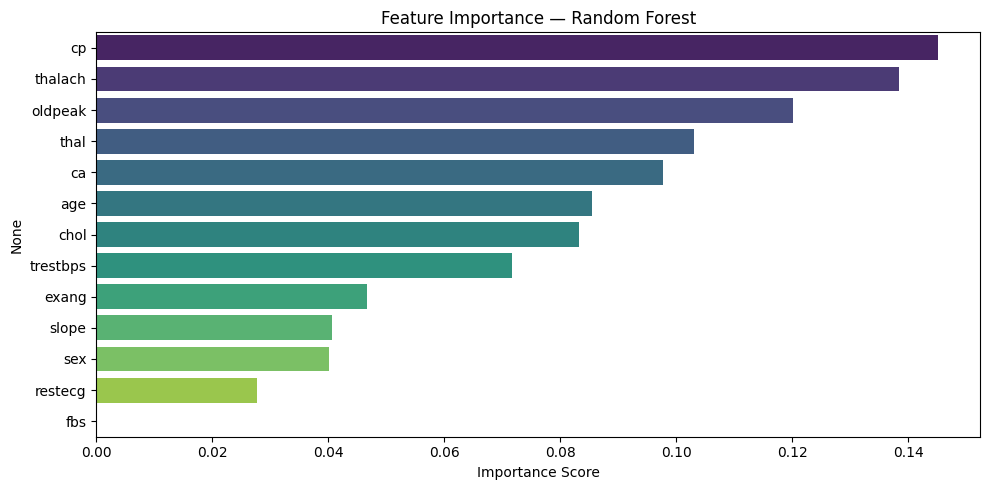


── Top 5 Most Important Features ──
cp         0.145101
thalach    0.138390
oldpeak    0.120162
thal       0.102991
ca         0.097686
dtype: float64


In [15]:
# ── FEATURE IMPORTANCE  ─────────────────────
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print('\n── Top 5 Most Important Features ──')
print(feat_imp.head(5))

## STEP 9 — SAVE THE MODEL

**Why save the model?**

Your Streamlit app runs separately from this notebook.
So you train the model here → save it as a file → Streamlit loads that file.

Think of it like baking a cake (training) and storing it in a box (joblib.dump).
The app just opens the box (joblib.load) and serves it!

We save **Random Forest** because it had better accuracy.

In [16]:
# ── SAVE MODEL — NEW but simple ───────────────────────────────
# joblib.dump(what_to_save, 'filename')
joblib.dump(rf_model, 'heart_model.pkl')

# Also save the feature column names
# So the app knows which columns to expect in the right order
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print('Model saved as heart_model.pkl ✅')
print('Feature names saved as feature_names.pkl ✅')
print('\nRandom Forest Accuracy:', f"{accuracy_score(y_test, rf_pred)*100:.2f}%")

Model saved as heart_model.pkl ✅
Feature names saved as feature_names.pkl ✅

Random Forest Accuracy: 85.25%


## STEP 10 — STREAMLIT APP

**How this works (same as AICTE_2):**
- `%%writefile app.py` saves everything below into a file called `app.py`
- Then we run that file with streamlit

**The app has 2 tabs (same as AICTE_2 had tabs):**
- Tab 1: Enter health details → ML prediction + Gemini explanation
- Tab 2: Gemini gives diet/lifestyle tips based on what you entered

**Replace `YOUR_GEMINI_API_KEY` with your actual key before running!**

In [17]:
%%writefile app.py
# ============================================================
# HEART DISEASE PREDICTOR — STREAMLIT APP
# Uses: ML model (Random Forest) + Gemini AI
# ============================================================

import streamlit as st
import numpy as np
import joblib
import google.generativeai as genai

# ── SETUP ────────────────────────────────────────────────────
# configure Gemini with your API key
genai.configure(api_key="YOUR_API_KEY")
model_gemini = genai.GenerativeModel("gemini-2.5-flash")

# Load the saved ML model and feature names
# joblib.load is the opposite of joblib.dump — opens the saved box!
rf_model = joblib.load('heart_model.pkl')
feature_names = joblib.load('feature_names.pkl')

# ── PAGE SETUP ───────────────────────────────────────────────

st.set_page_config(
    page_title="Heart Disease Predictor",
    page_icon="❤️",
    layout="wide"
)

st.title("❤️ Heart Disease Predictor")
st.write("Enter your health details below. The ML model will predict your risk, and Gemini AI will explain the result.")
st.markdown("---")

# ── 2 TABS ────────────────────────
tab1, tab2 = st.tabs(["🔬 Prediction", "🥗 Diet & Lifestyle Tips"])


# ════════════════════════════════════════════════════════════
# TAB 1 — PREDICTION
# User fills in their health values → model predicts → Gemini explains
# ════════════════════════════════════════════════════════════
with tab1:
    st.subheader("Enter Your Health Details")

    # ── INPUT FORM ───────────────────────────────────────────
    # Two columns so it doesn't look too long
    col1, col2 = st.columns(2)

    with col1:
        age      = st.number_input("Age", min_value=20, max_value=100, value=45)
        sex      = st.selectbox("Sex", options=[1, 0],
                                format_func=lambda x: "Male" if x == 1 else "Female")
        cp       = st.selectbox("Chest Pain Type",
                                options=[0, 1, 2, 3],
                                format_func=lambda x: [
                                    "0 — Typical angina",
                                    "1 — Atypical angina",
                                    "2 — Non-anginal pain",
                                    "3 — Asymptomatic"
                                ][x])
        trestbps = st.number_input("Resting Blood Pressure (mm Hg)",
                                   min_value=80, max_value=200, value=120)
        chol     = st.number_input("Cholesterol (mg/dl)",
                                   min_value=100, max_value=600, value=200)
        fbs      = st.selectbox("Fasting Blood Sugar > 120 mg/dl",
                                options=[0, 1],
                                format_func=lambda x: "Yes" if x == 1 else "No")
        restecg  = st.selectbox("Resting ECG",
                                options=[0, 1, 2],
                                format_func=lambda x: [
                                    "0 — Normal",
                                    "1 — ST-T wave abnormality",
                                    "2 — Left ventricular hypertrophy"
                                ][x])

    with col2:
        thalach  = st.number_input("Max Heart Rate Achieved",
                                   min_value=60, max_value=220, value=150)
        exang    = st.selectbox("Exercise Induced Chest Pain",
                                options=[0, 1],
                                format_func=lambda x: "Yes" if x == 1 else "No")
        oldpeak  = st.number_input("ST Depression (oldpeak)",
                                   min_value=0.0, max_value=7.0,
                                   value=1.0, step=0.1)
        slope    = st.selectbox("Slope of Peak Exercise ST Segment",
                                options=[0, 1, 2],
                                format_func=lambda x: [
                                    "0 — Upsloping",
                                    "1 — Flat",
                                    "2 — Downsloping"
                                ][x])
        ca       = st.selectbox("Number of Major Vessels (0-3)",
                                options=[0, 1, 2, 3])
        thal     = st.selectbox("Thal",
                                options=[0, 1, 2, 3],
                                format_func=lambda x: [
                                    "0 — Normal",
                                    "1 — Fixed defect",
                                    "2 — Reversible defect",
                                    "3 — Other"
                                ][x])

    # ── PREDICT BUTTON ───────────────────────────────────────
    if st.button("🔍 Predict Now", use_container_width=True):

        # Build input array in the same column order as training
        # This is why we saved feature_names.pkl !
        input_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                                 restecg, thalach, exang, oldpeak,
                                 slope, ca, thal]])

        # Get prediction (0 or 1) and probability
        prediction   = rf_model.predict(input_data)[0]
        probability  = rf_model.predict_proba(input_data)[0]
        confidence   = probability[prediction] * 100

        # ── SHOW RESULT ──────────────────────────────────────
        st.markdown("---")
        if prediction == 1:
            st.error(f"⚠️ **Heart Disease Detected** — Confidence: {confidence:.1f}%")
        else:
            st.success(f"✅ **No Heart Disease Detected** — Confidence: {confidence:.1f}%")

        # ── GEMINI EXPLANATION ───────────────────────────────
        # — build a prompt, send to Gemini
        result_text = "Heart Disease" if prediction == 1 else "No Heart Disease"

        prompt = f"""
        A patient has been assessed with these health details:
        - Age: {age}, Sex: {'Male' if sex==1 else 'Female'}
        - Chest Pain Type: {cp}, Resting BP: {trestbps} mm Hg
        - Cholesterol: {chol} mg/dl, Fasting Blood Sugar >120: {'Yes' if fbs==1 else 'No'}
        - Max Heart Rate: {thalach}, Exercise Chest Pain: {'Yes' if exang==1 else 'No'}
        - ST Depression: {oldpeak}, Major Vessels: {ca}

        The ML model predicted: **{result_text}** with {confidence:.1f}% confidence.

        Please:
        1. Explain this result in very simple words (2-3 sentences, no medical jargon)
        2. Point out which 2-3 values from their inputs seem most concerning or reassuring
        3. End with: "Please consult a doctor for proper medical advice."

        Keep the tone calm and supportive. Use bullet points.
        """

        with st.spinner("Gemini is analyzing your results..."):
            response = model_gemini.generate_content(prompt)

        st.markdown("### 🤖 Gemini's Explanation")
        st.markdown(response.text)

        # Store inputs in session_state so Tab 2 can use them
        # session_state = Streamlit's way of passing data between tabs
        st.session_state['inputs'] = {
            'age': age, 'sex': sex, 'chol': chol,
            'trestbps': trestbps, 'fbs': fbs,
            'thalach': thalach, 'prediction': result_text
        }

        st.info("💡 Go to the **Diet & Lifestyle Tips** tab for personalised advice!")


# ════════════════════════════════════════════════════════════
# TAB 2 — DIET & LIFESTYLE TIPS
# Gemini gives personalised tips based on the user's inputs
# ════════════════════════════════════════════════════════════
with tab2:
    st.subheader("🥗 Personalised Diet & Lifestyle Tips")

    # Check if user has done a prediction yet
    if 'inputs' not in st.session_state:
        st.info("👈 First go to the Prediction tab and click Predict Now. Then come back here!")
    else:
        inp = st.session_state['inputs']

        st.markdown(f"**Based on your results: {inp['prediction']}**")
        st.markdown("Gemini will now give you personalised tips based on your specific values.")

        if st.button("🥗 Get My Tips", use_container_width=True):

            tips_prompt = f"""
            A patient with these details:
            - Age: {inp['age']}, Sex: {'Male' if inp['sex']==1 else 'Female'}
            - Cholesterol: {inp['chol']} mg/dl
            - Resting Blood Pressure: {inp['trestbps']} mm Hg
            - Fasting Blood Sugar >120: {'Yes' if inp['fbs']==1 else 'No'}
            - Max Heart Rate: {inp['thalach']}
            - ML Prediction: {inp['prediction']}

            Give them a friendly, personalised health plan with:
            1. 🥗 3 specific diet tips (mention actual foods based on their cholesterol/BP values)
            2. 🏃 3 specific exercise tips suited to their age and heart rate
            3. 😴 2 lifestyle habits to adopt
            4. ⚠️ 2 things they should strictly avoid

            Use simple language, be encouraging, and use emojis.
            End with a reminder to consult a doctor.
            """

            with st.spinner("Gemini is preparing your personalised plan..."):
                tips_response = model_gemini.generate_content(tips_prompt)

            st.markdown(tips_response.text)

Writing app.py


## STEP 11 — RUN THE APP

Same exact method as AICTE_2 — kill old streamlit, start new one, open with localtunnel.

**You will get a URL like:** `https://xxxx.loca.lt`
Open that URL → your app is live!

In [18]:
!pkill -f streamlit

import subprocess, time
time.sleep(2)

subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port=8501'])
time.sleep(3)

print('✅ Streamlit is running!')
print('Opening tunnel...')

!npx --yes localtunnel --port 8501

✅ Streamlit is running!
Opening tunnel...
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://bumpy-birds-count.loca.lt
^C
